## Contextualisation du projet:
Il s'agit d'un projet de `détection de fraudes` fiscales au sein de la DGI du Cameroun.

## Objectif:
L'objectif est d'anticiper les comportements de fraudes fiscales avec une **précision** et un **recall** d'au moins **80%**

### EDA
### Objectif de l'EDA
Comprendre au maximum les données pour adopter une stratégie de modélisation

## Analyse de la forme:
- **Variable cible**: Fraude (Pas de fraude, fraude faible, fraude élevée)
- **Dimensions du dataset**: 11 798 lignes et 29 colonnes
- **Types de variables**: Une seule variable numérique(Nombre_d'activités_2024) contre 28 colonnes categorielles, elles ont pour la plupart été discrétisées par faciliter l'analyse multidimensionnelle
- **Valeurs manquantes**: Aucune valeur manquante

## Analyse du fond:
- **Vidualisation de la variable cible**: 6136 comportements légaux, 4466 Fraudes faibles et 1196 Fraudes élevées
- **Compréhension des variables**: RAS
- **Visualisation des différentes variables**: OK

### Analyse bivariée
- **Visualisation des relations variables explicatrices - variable cible**
    - **Quali - target**: Les variables *Type_de_centre*, *Régime*, *Décla24*, *conformité de déclaration des marchés en 2019*, *MinCA19*, *MinCA20*, *Nombre des prestations de marchés*, *comportement déclaratif des DSF par rapport au cumul mensuel*, *SERM*, *SFBME*, *SPSOE*, *STLM* semblent influencer significativement le comportement de fraude. (Hypothèses à tester)

    - **Quanti - target**: La variable *Nombre_dactivtés_2024* semble influencer significativement la fraude fiscale (Hpothèse à tester).
- **Visualisation des relations quali- quali**: Le régime fiscal(REEL, IGS) influence le comportement de déclaration des contribuables des MP(En 2024 en l'occurence). Les variables *Regime*, *Nbprestation_marchés*, *comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024* et *Decla24* sont visiblement liées.
- **Visualisation des relations quali- quanti**: La variable *Nombre d'activités 2024* est très liée à la variable *Decla24*, les autres variables catégorielles *Type_de_centre*, *Regime*, *Decla24*, *Conformité de déclaration de marchés en 2019*, *MinCA19*, *MinCA20*,
*Nbprestation_marchés*, *Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024*, *SERM*, *SFBME*, *SPSOE*, *STLM*
- **Visualisation des relations quanti-quanti**: Une seule variable quantitative.
- **Identification des outliers**: Quelques outliers présents dans la variable `Nombre_dactivtés_2024`

### Test statistiques
- **Relations Quali - Target(Test de Chi2)**:
    - Hypothèse H0: `La variable (explicatrice) n'influence pas la fraude dans les marchés publics`
    - Résultats: H0 rejétée pour toutes les variables

In [1]:
import pandas as pd
df = pd.read_excel("C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/data/raw/Données_Marchés_publics_2024.xlsx")
df.head()

,ident,Type_de_centre,Regime,Persojuri,gctax (groupe de compte de gestion des contribuables),Type de déclarant des MP dans les DSF,MinCA19,Conformité de déclaration de marchés en 2019,Conformité de déclaration de marchés en 2020,Conformité de déclaration de marchés en 2021,...,Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024,MontantMP24,DSF23,SBTP,SERM,SFBME,SPSOE,Actif2024,STLM,Fraude
0,1,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Oui,MND,MD,MD,...,Bonne déclaration,1603333,Oui,Oui,Oui,Oui,Oui,Oui,Oui,Risque faible
1,2,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Oui,MND,MD,MD,...,Mauvaise déclaration,1788690,Oui,Oui,Non,Oui,Oui,Oui,Non,Pas de risque
2,3,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,...,Mauvaise déclaration,88743200,Oui,Non,Non,Oui,Non,Oui,Non,Pas de risque
3,4,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,...,Mauvaise déclaration,14800000,Oui,Oui,Non,Non,Non,Oui,Non,Pas de risque
4,5,DGE,IGS,Morale,Petits comptes,Déclarants permanents,Non,MD,NPC,NPC,...,Mauvaise déclaration,12703175,Oui,Non,Non,Non,Non,Oui,Oui,Pas de risque


### Analyse de la forme

In [2]:
df.shape

(11798, 29)

In [3]:
# Types de variables 
df.dtypes

ident                                                                         int64
Type_de_centre                                                               object
Regime                                                                       object
Persojuri                                                                    object
gctax (groupe de compte de gestion des contribuables)                        object
Type de déclarant des MP dans les DSF                                        object
MinCA19                                                                      object
Conformité de déclaration de marchés en 2019                                 object
Conformité de déclaration de marchés en 2020                                 object
Conformité de déclaration de marchés en 2021                                 object
Conformité de déclaration de marchés en 2022                                 object
Conformité de déclaration de marchés en 2023                                

In [4]:
# valeurs manquantes
df.isna().sum()

ident                                                                        0
Type_de_centre                                                               0
Regime                                                                       0
Persojuri                                                                    0
gctax (groupe de compte de gestion des contribuables)                        0
Type de déclarant des MP dans les DSF                                        0
MinCA19                                                                      0
Conformité de déclaration de marchés en 2019                                 0
Conformité de déclaration de marchés en 2020                                 0
Conformité de déclaration de marchés en 2021                                 0
Conformité de déclaration de marchés en 2022                                 0
Conformité de déclaration de marchés en 2023                                 0
MinCA20                                             

### Analyse du fond

In [5]:
# Vidualisation de la variable cible
df['Fraude'].value_counts()

Fraude
Pas de risque    5711
Risque faible    3935
Risque élevé     2152
Name: count, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\1885919221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x=df['Fraude'], palette=sns.color_palette("RdYlGn_r", 3), order=ordre)


Text(0.5, 1.0, 'Comportements fiscaux des contribuables des marchés publics en 2024')

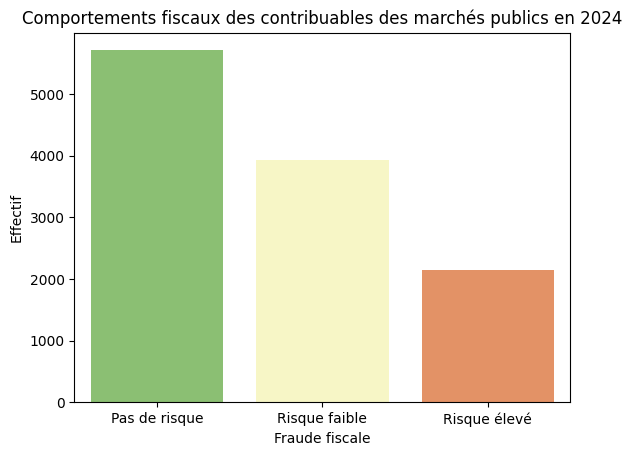

In [6]:
# Vidualisation de la variable cible
import seaborn as sns
import matplotlib.pyplot as plt

ordre = ['Pas de risque', 'Risque faible', 'Risque élevé']
sns.countplot(df, x=df['Fraude'], palette=sns.color_palette("RdYlGn_r", 3), order=ordre)
plt.xlabel('Fraude fiscale')
plt.ylabel('Effectif')
plt.title("Comportements fiscaux des contribuables des marchés publics en 2024")
#plt.savefig('C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures_EDA/target.png')

In [7]:
df['Fraude'].value_counts()

Fraude
Pas de risque    5711
Risque faible    3935
Risque élevé     2152
Name: count, dtype: int64

<Axes: xlabel='MontantMP24'>

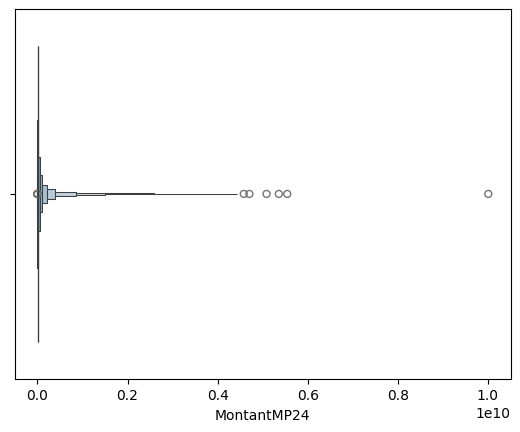

In [8]:
sns.boxenplot(df, x=df['MontantMP24'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\2149029350.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


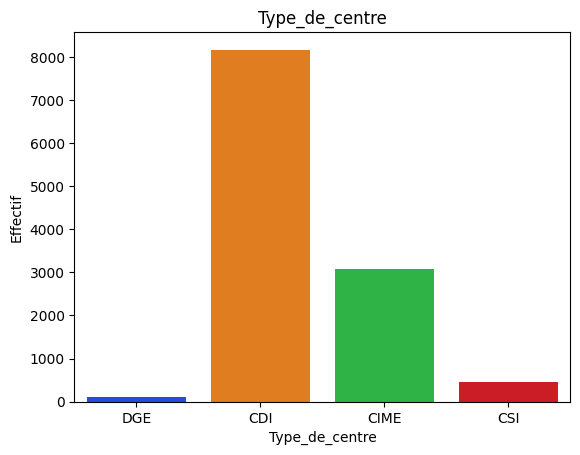

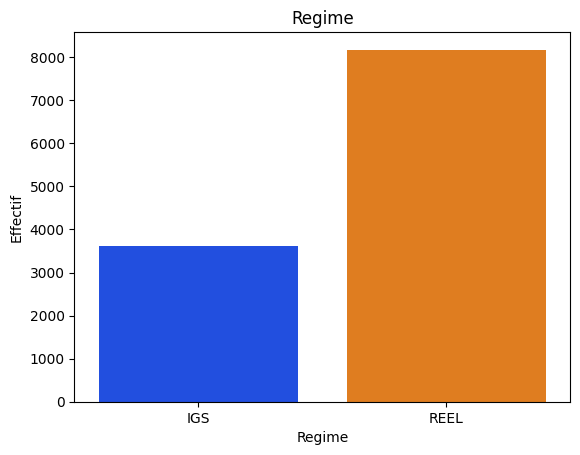

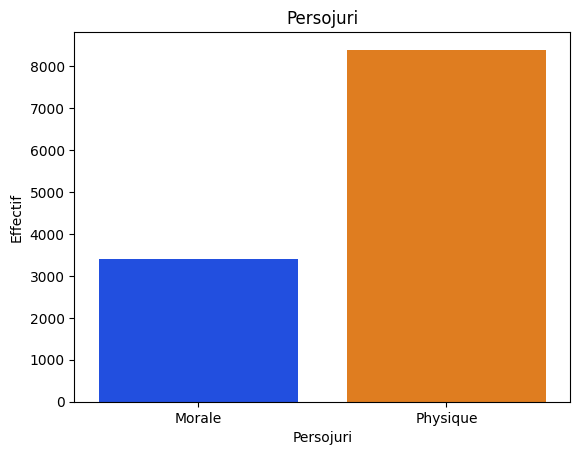

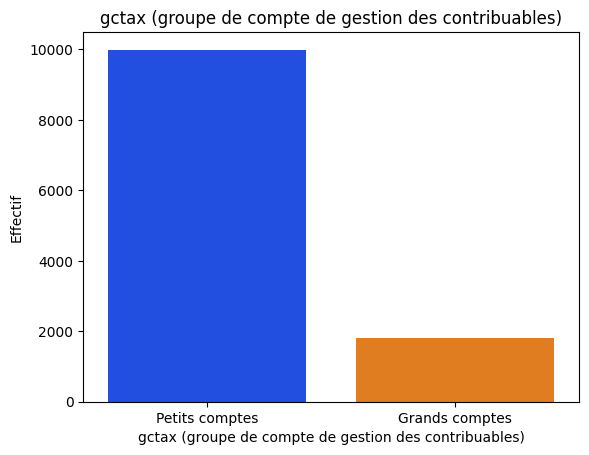

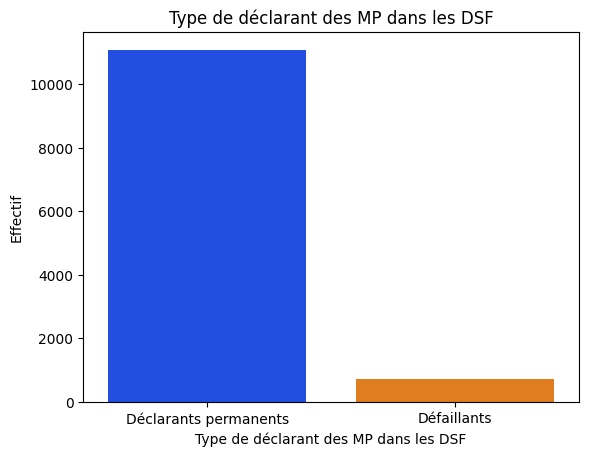

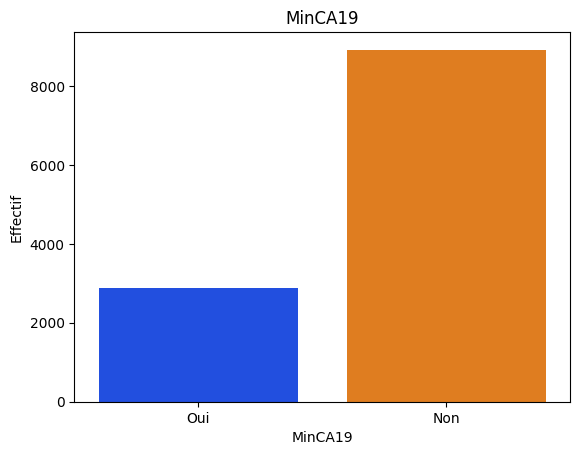

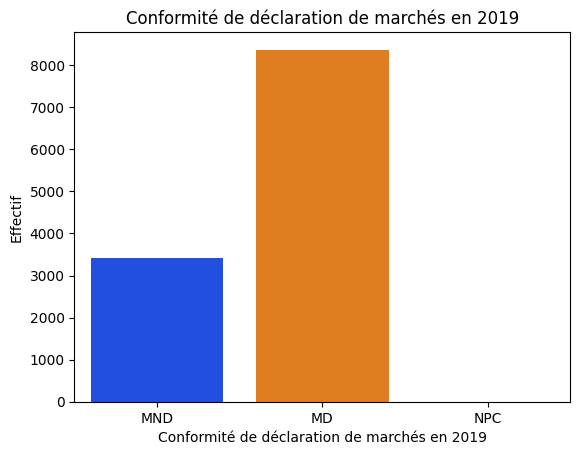

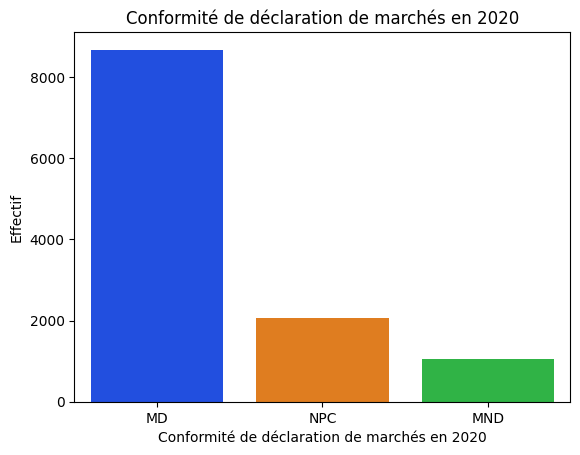

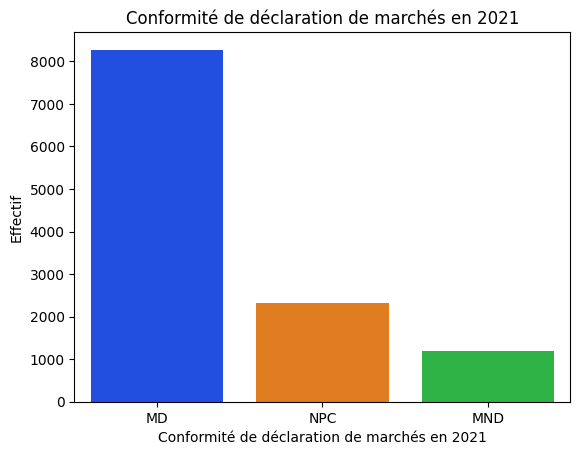

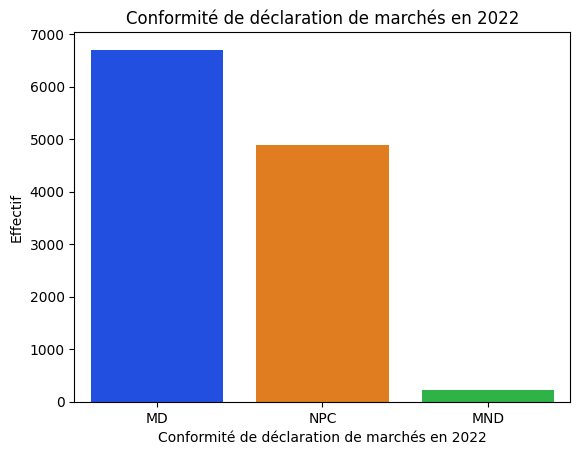

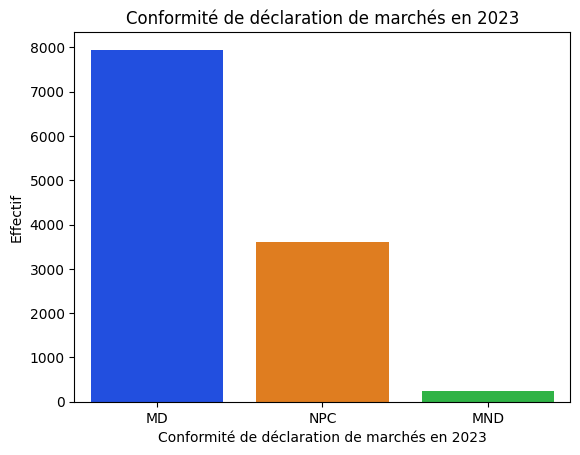

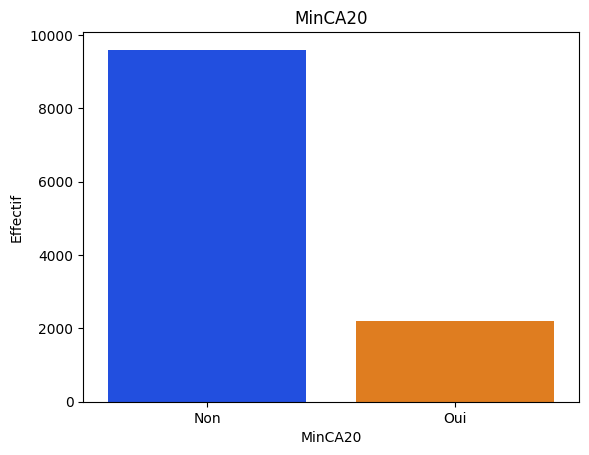

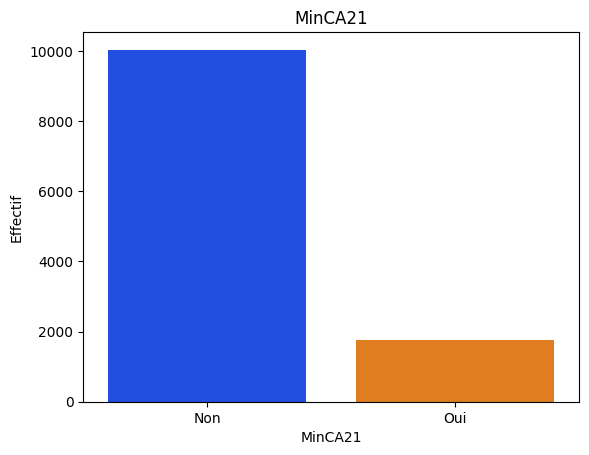

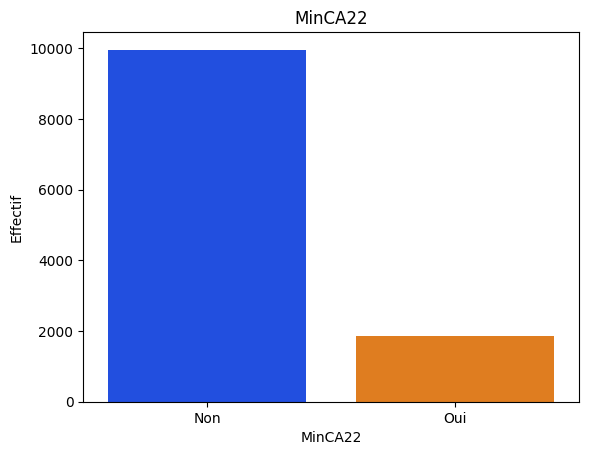

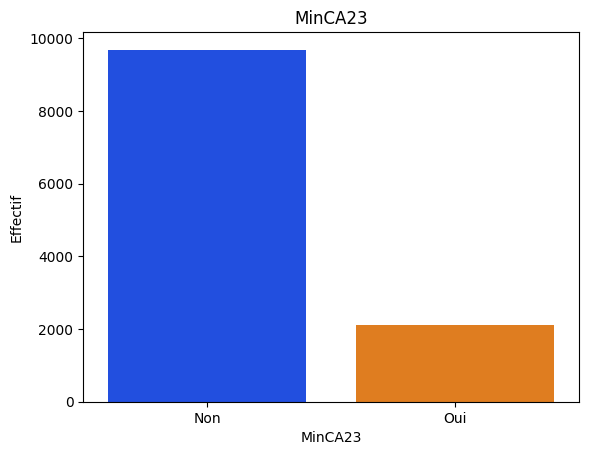

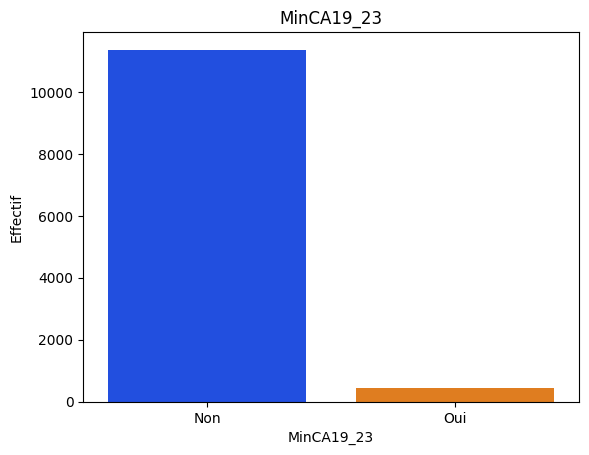

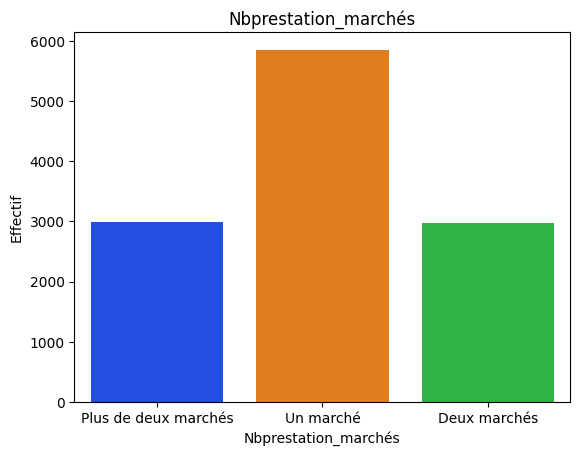

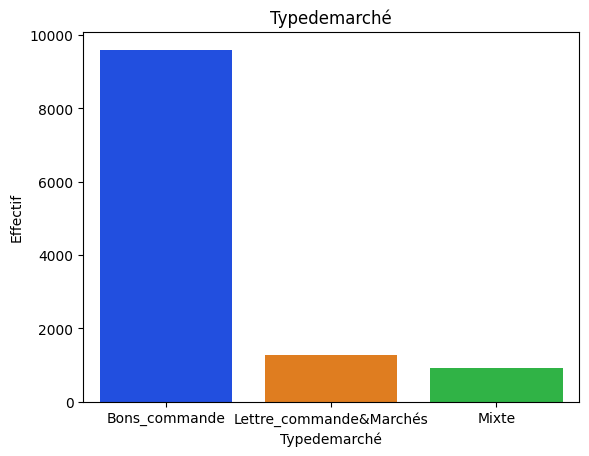

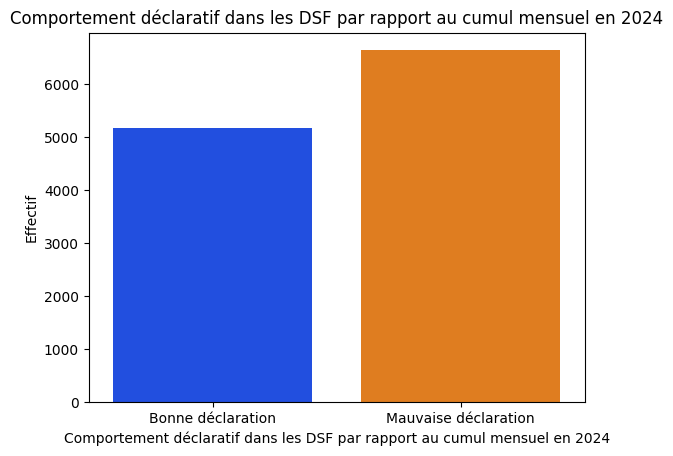

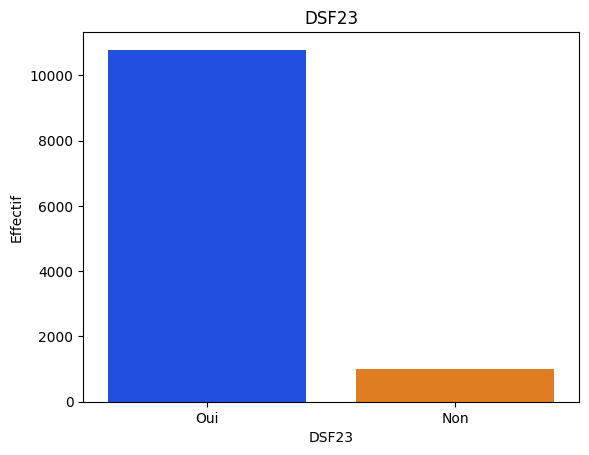

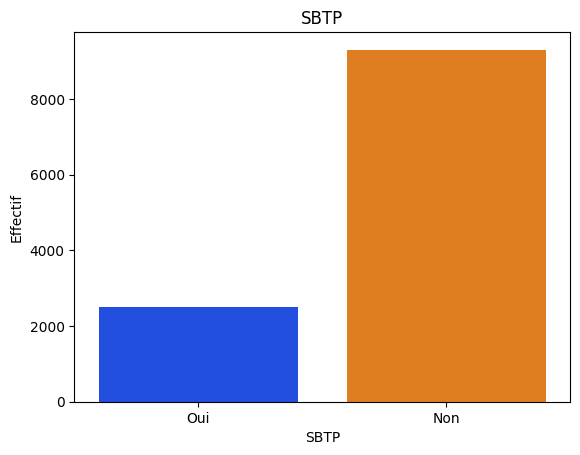

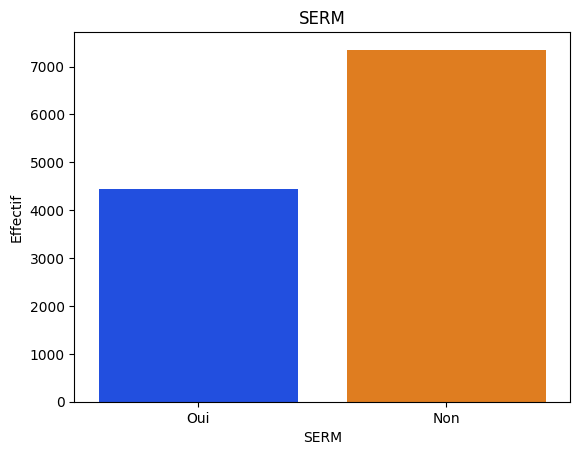

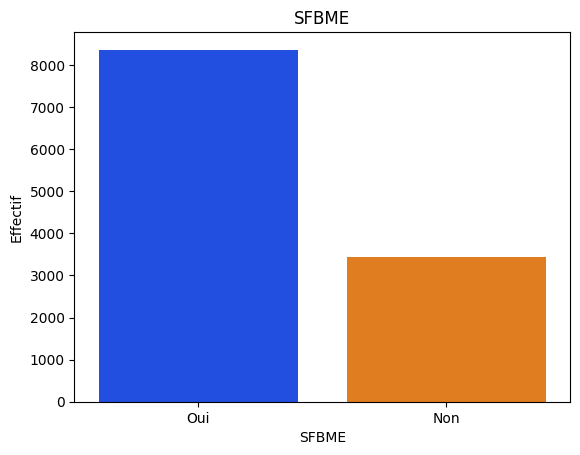

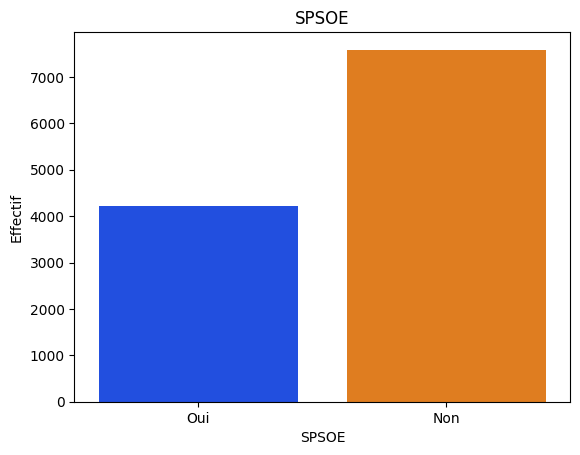

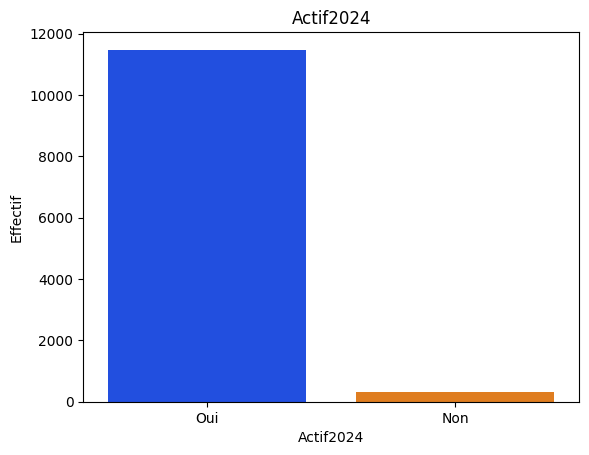

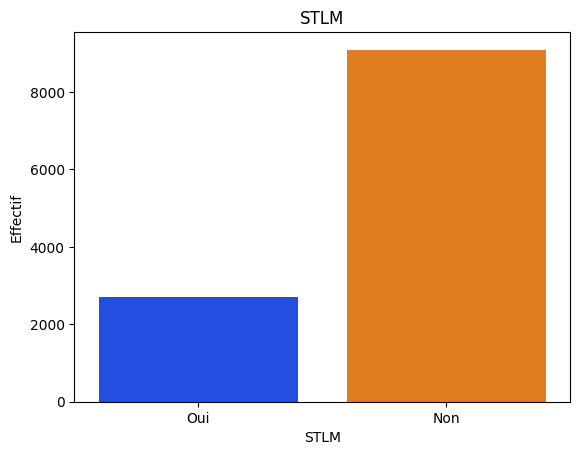

In [9]:
# Visualisation des différentes variables
for c in df.select_dtypes('object').drop('Fraude', axis=1).columns:
    plt.figure()
    sns.countplot(df, x=df[c], hue=df[c], palette='bright')
    plt.ylabel('Effectif')
    plt.title(f'{c}')

In [10]:
stats = df.describe(include=["object", "category", "bool"])
stats.to_excel('statistiques_descriptives.xlsx', index=False)
stats

,Type_de_centre,Regime,Persojuri,gctax (groupe de compte de gestion des contribuables),Type de déclarant des MP dans les DSF,MinCA19,Conformité de déclaration de marchés en 2019,Conformité de déclaration de marchés en 2020,Conformité de déclaration de marchés en 2021,Conformité de déclaration de marchés en 2022,...,Typedemarché,Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024,DSF23,SBTP,SERM,SFBME,SPSOE,Actif2024,STLM,Fraude
count,11798,11798,11798,11798,11798,11798,11798,11798,11798,11798,...,11798,11798,11798,11798,11798,11798,11798,11798,11798,11798
unique,4,2,2,2,2,2,3,3,3,3,...,3,2,2,2,2,2,2,2,2,3
top,CDI,REEL,Physique,Petits comptes,Déclarants permanents,Non,MD,MD,MD,MD,...,Bons_commande,Mauvaise déclaration,Oui,Non,Non,Oui,Non,Oui,Non,Pas de risque
freq,8172,8172,8389,9992,11083,8916,8368,8674,8273,6701,...,9606,6634,10781,9306,7352,8360,7586,11474,9093,5711


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\2986753923.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


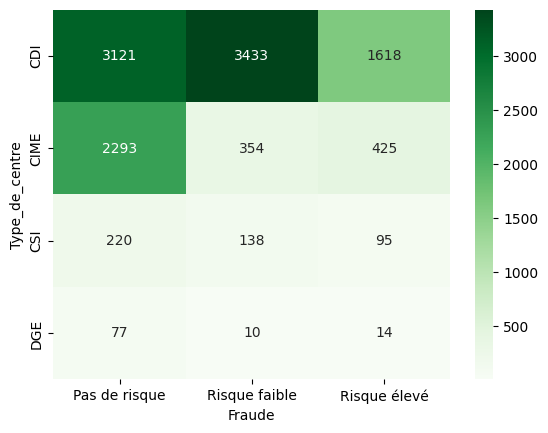

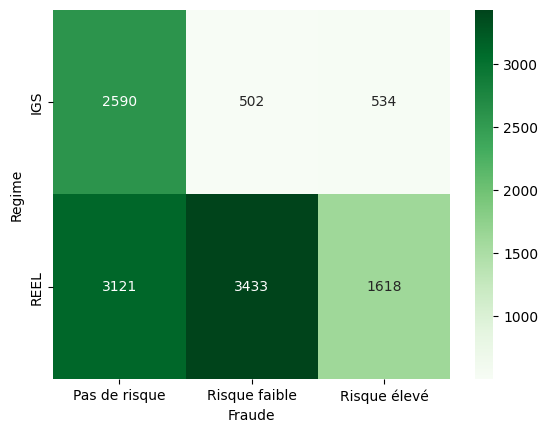

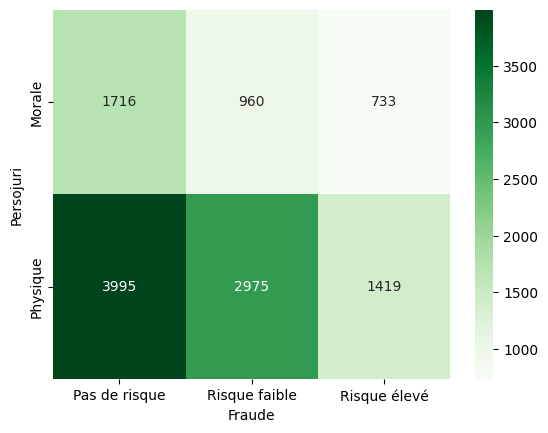

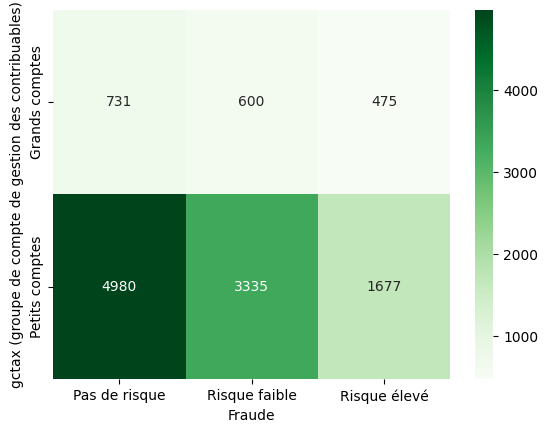

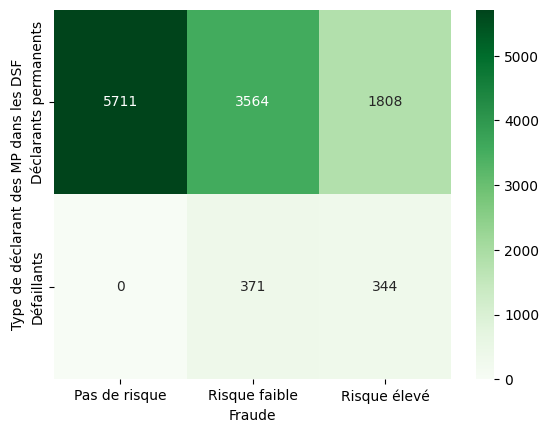

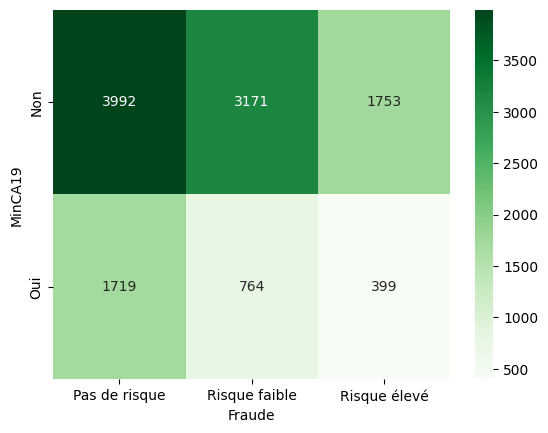

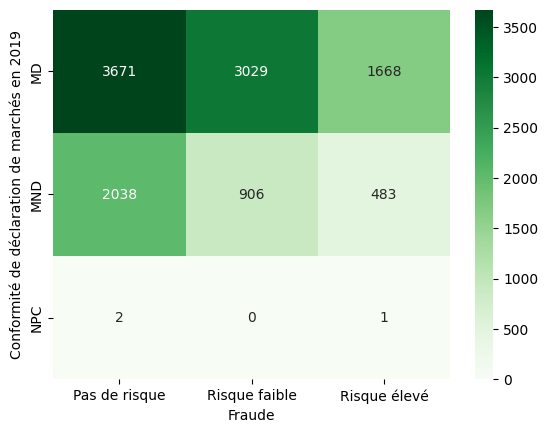

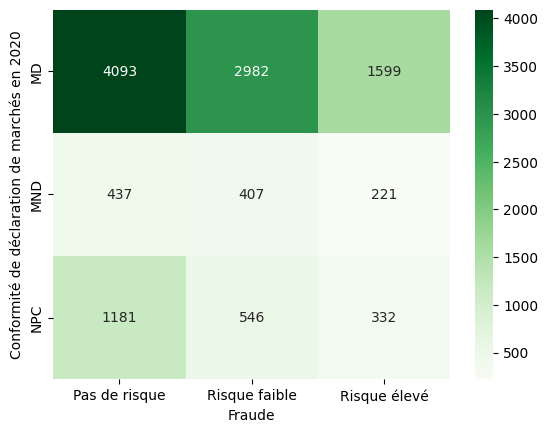

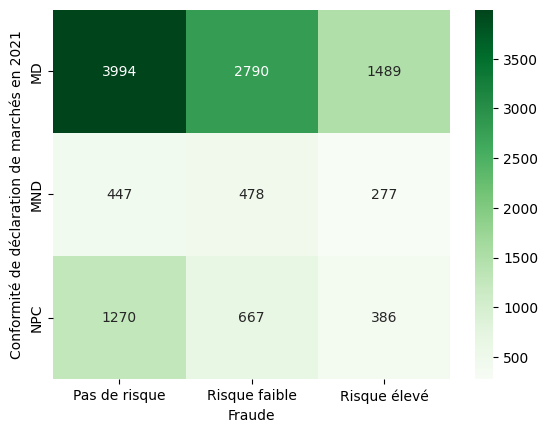

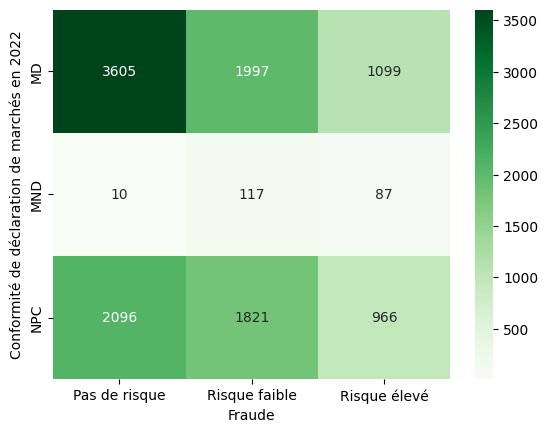

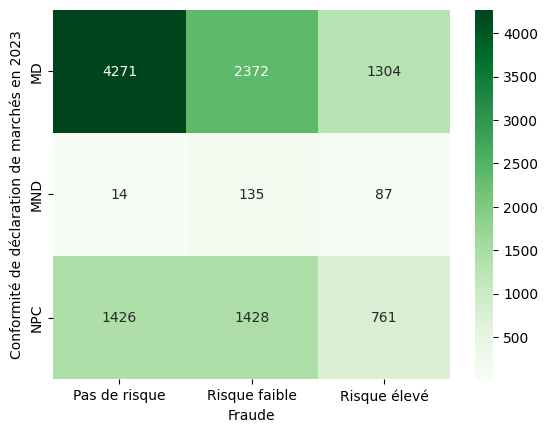

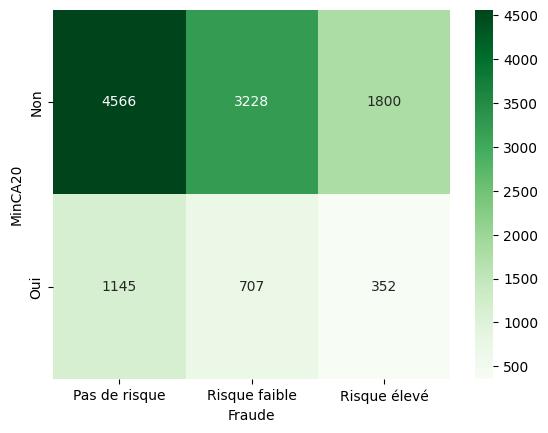

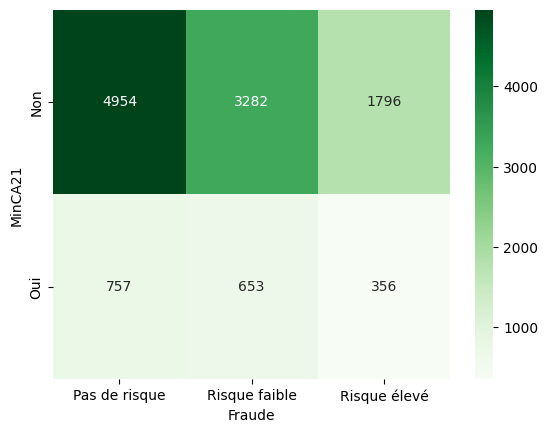

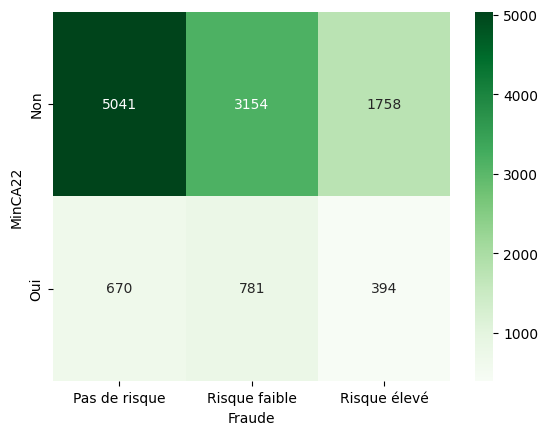

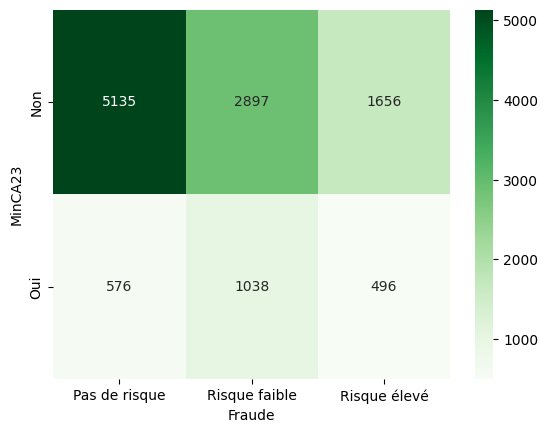

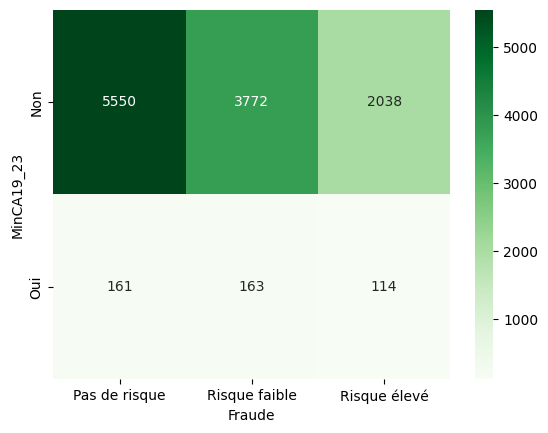

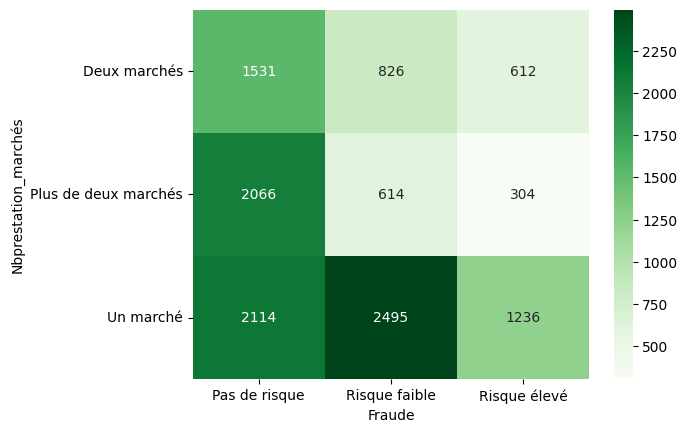

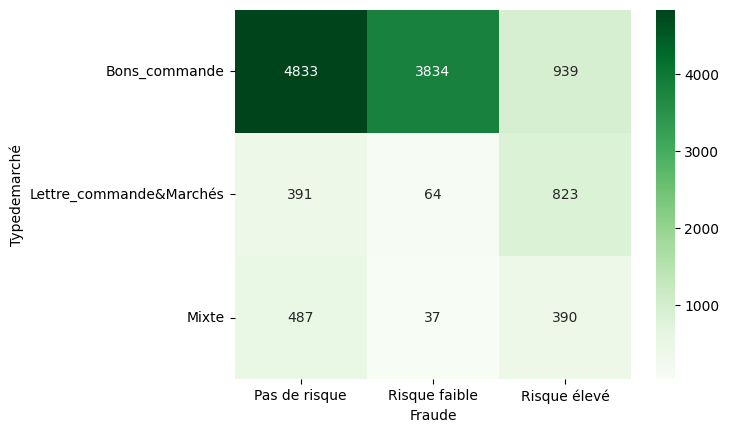

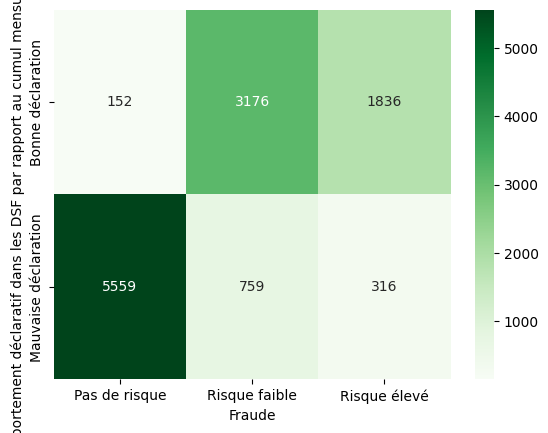

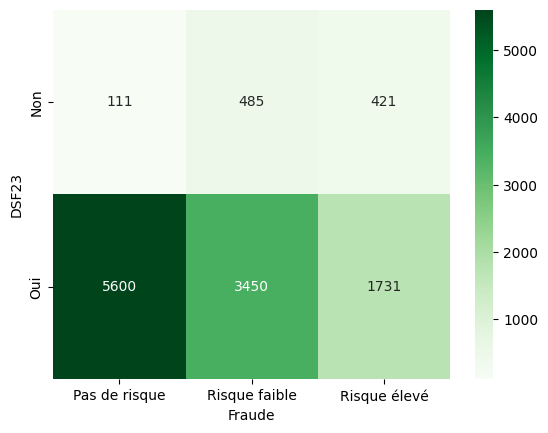

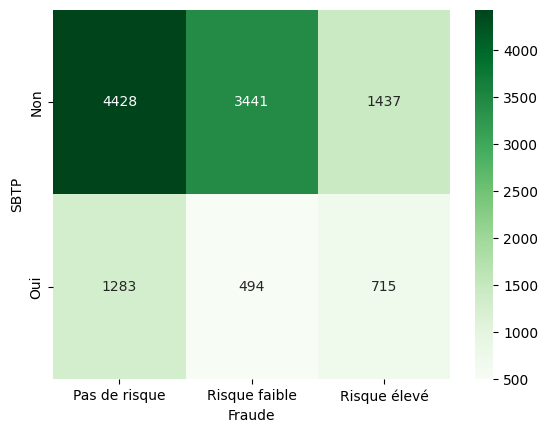

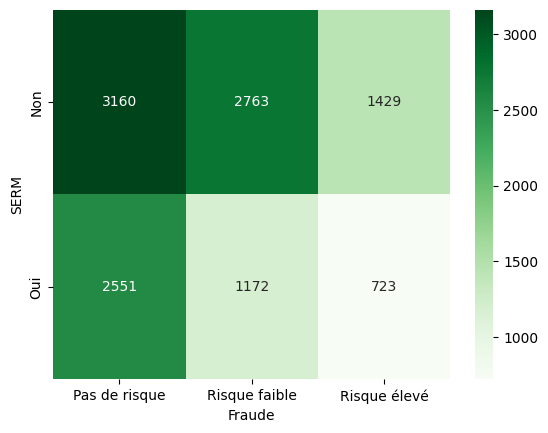

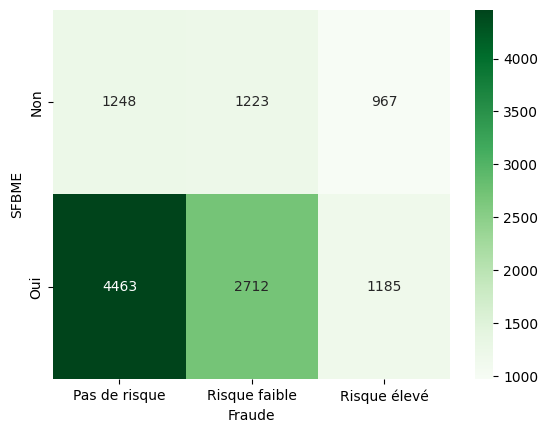

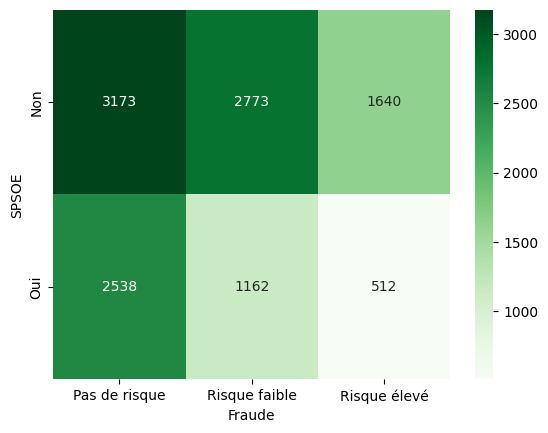

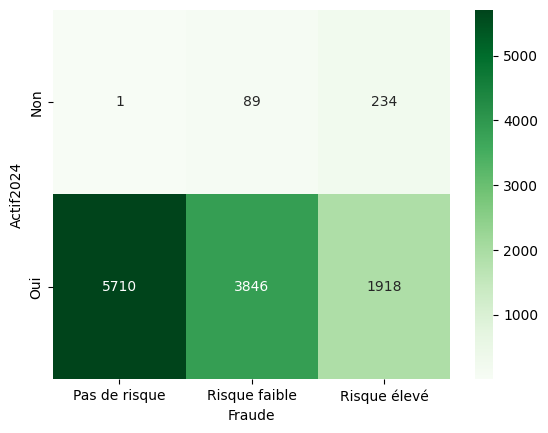

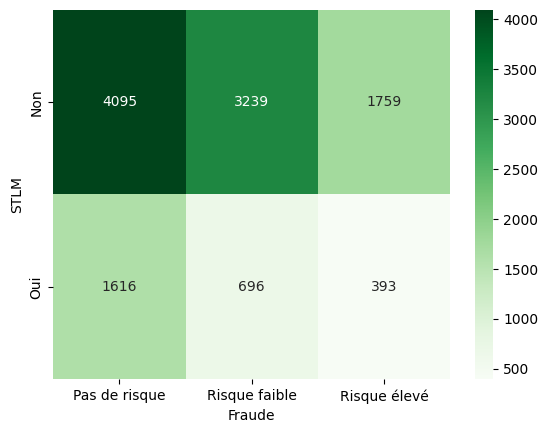

In [11]:
# Visualisation Quali - target
for c in df.select_dtypes('object').drop('Fraude', axis=1).columns:
    plt.figure()
    sns.heatmap(pd.crosstab(df[c], df['Fraude']), cmap="Greens", annot=True, fmt="d")

In [12]:
df.columns

Index(['ident', 'Type_de_centre', 'Regime', 'Persojuri',
       'gctax (groupe de compte de gestion des contribuables)',
       'Type de déclarant des MP dans les DSF', 'MinCA19',
       'Conformité de déclaration de marchés en 2019',
       'Conformité de déclaration de marchés en 2020',
       'Conformité de déclaration de marchés en 2021',
       'Conformité de déclaration de marchés en 2022',
       'Conformité de déclaration de marchés en 2023', 'MinCA20', 'MinCA21',
       'MinCA22', 'MinCA23', 'MinCA19_23', 'Nbprestation_marchés',
       'Typedemarché',
       'Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024',
       'MontantMP24', 'DSF23', 'SBTP', 'SERM', 'SFBME', 'SPSOE', 'Actif2024',
       'STLM', 'Fraude'],
      dtype='object')

## Test de Chi2

In [13]:
from scipy.stats import chi2_contingency

# fonction pour le test
def chi2_test(df, var, target='Fraude', alpha=0.05):
    # construction des groupes
    contengency = pd.crosstab(df[var], df[target])

    stat, p, dof, expected = chi2_contingency(contengency)

    if p < alpha:
        return f"H0 rejetée (p = {p:.4f})"
    else:
        return f"H0 non rejetée (p = {p:.4f})"

In [14]:
df.drop('Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024', axis=1, inplace=True)

In [15]:
# test proprement dit
for col in df.select_dtypes('object').drop('Fraude', axis=1).columns:
    print(f"{col:-<50}{chi2_test(df, col)}")

Type_de_centre------------------------------------H0 rejetée (p = 0.0000)
Regime--------------------------------------------H0 rejetée (p = 0.0000)
Persojuri-----------------------------------------H0 rejetée (p = 0.0000)
gctax (groupe de compte de gestion des contribuables)H0 rejetée (p = 0.0000)
Type de déclarant des MP dans les DSF-------------H0 rejetée (p = 0.0000)
MinCA19-------------------------------------------H0 rejetée (p = 0.0000)
Conformité de déclaration de marchés en 2019------H0 rejetée (p = 0.0000)
Conformité de déclaration de marchés en 2020------H0 rejetée (p = 0.0000)
Conformité de déclaration de marchés en 2021------H0 rejetée (p = 0.0000)
Conformité de déclaration de marchés en 2022------H0 rejetée (p = 0.0000)
Conformité de déclaration de marchés en 2023------H0 rejetée (p = 0.0000)
MinCA20-------------------------------------------H0 rejetée (p = 0.0003)
MinCA21-------------------------------------------H0 rejetée (p = 0.0000)
MinCA22----------------------------

In [16]:
from scipy.stats import chi2_contingency
import numpy as np

# Fonction pour calculer le V de Cramér
def cramers_v(df, var, target='Fraude'):
    contingency = pd.crosstab(df[var], df[target])
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# Fonction pour classer toutes les variables catégorielles
def cramers_v_all(df, target='Fraude'):
    results = {}
    for col in df.select_dtypes(include='object').columns:
        if col != target:  # on ne calcule pas sur la cible elle-même
            try:
                results[col] = cramers_v(df, col, target=target)
            except Exception as e:
                print(f"⚠️ Erreur avec {col}: {e}")
    # Convertir en DataFrame et trier par ordre décroissant
    return pd.DataFrame(results.items(), columns=["Variable", "V_de_Cramer"]).sort_values(
        by="V_de_Cramer", ascending=False
    ).reset_index(drop=True)

# Exemple d'utilisation
impact_vars = cramers_v_all(df, target="Fraude")
impact_vars

,Variable,V_de_Cramer
0,Typedemarché,0.352486
1,Regime,0.319714
2,Type de déclarant des MP dans les DSF,0.263502
3,DSF23,0.246852
4,Actif2024,0.242694
5,Type_de_centre,0.236154
6,MinCA23,0.199361
7,Nbprestation_marchés,0.197747
8,SFBME,0.187339
9,SPSOE,0.181409


In [17]:
impact_vars.to_excel('Statistiques_V_de_CRAMER.xlsx', index=False)

## Analyse des correspondances multiples

In [18]:
import prince

# Ne garder que les variables catégorielles
X = df.select_dtypes(include='object').drop('Fraude', axis=1)

#Initialisation de l'ACM 
mca = prince.MCA(
    n_components=3,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=2
)

# Fit + transform
mca = mca.fit(X)
X_mca = mca.transform(X)

# Valeurs propres (inertie expliquée par axe)
eigvals = mca.eigenvalues_
# Valeurs propres
eigvals = mca.eigenvalues_

# Inertie expliquée (calcul manuel)
explained_inertia = eigvals / eigvals.sum()

In [19]:
explained_inertia

array([0.3860901 , 0.35761665, 0.25629325])

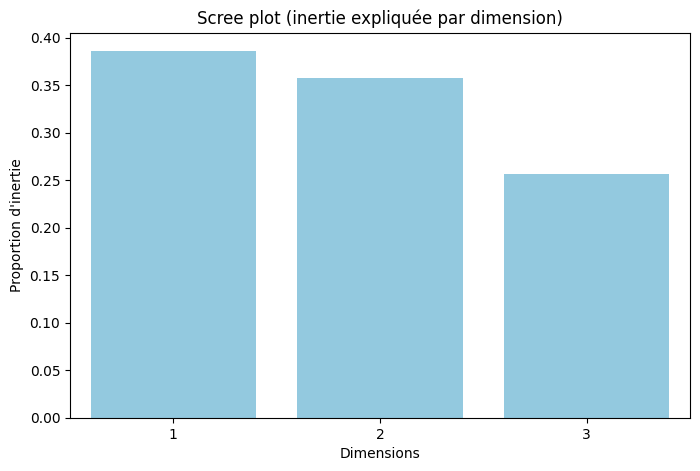

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x=range(1, len(explained_inertia)+1), y=explained_inertia, color="skyblue")
plt.title("Scree plot (inertie expliquée par dimension)")
plt.xlabel("Dimensions")
plt.ylabel("Proportion d'inertie")
#plt.savefig('C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures_EDA/contribution_des_axes.png')
plt.show()

In [21]:
#df.loc[df['Fraude'] == 'Risque faible', 'Fraude'] = 'Risqué'
#df.loc[df['Fraude'] == 'Risque élevé', 'Fraude'] = 'Risqué'

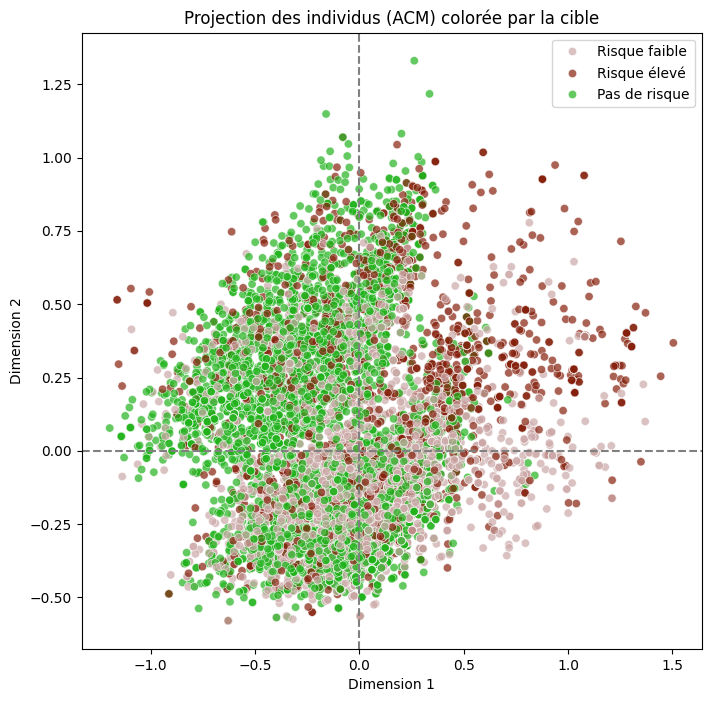

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

ordre = ['Risque faible', 'Risque élevé','Pas de risque']

# dictionnaire : catégorie -> couleur
palette_custom = {       # tu peux aussi mettre un code hex "#FF0000"
    'Risque élevé': "#85200C",
    'Pas de risque': "#21B31C",
    'Risque faible': "#CDA9A9"
}

plt.figure(figsize=(8,8))
sns.scatterplot(
    x=X_mca[0], 
    y=X_mca[2], 
    hue=df['Fraude'].values,       
    palette=palette_custom,        # ici on applique le dict
    hue_order=ordre, 
    alpha=0.7
)

plt.title("Projection des individus (ACM) colorée par la cible")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")

plt.savefig(
    'C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures_EDA/graphique_des_individus_ACM(Dim1_Dim3).png'
)
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\1893610386.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(coords_mod[0][i], coords_mod[2][i], txt, fontsize=9)


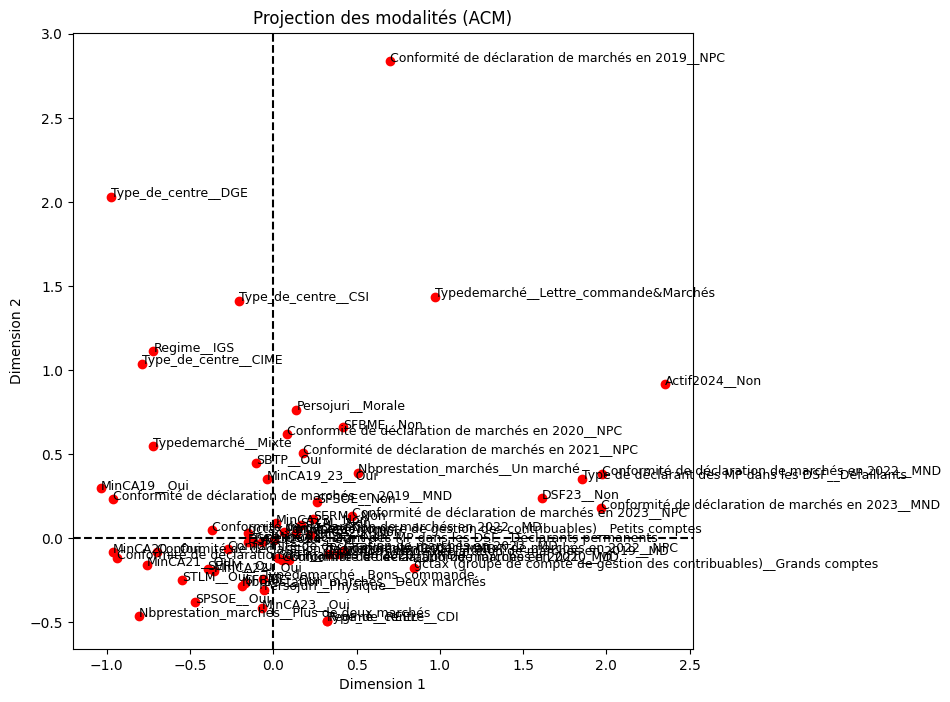

In [23]:
# 2️⃣ Coordonnées des modalités
coords_mod = mca.column_coordinates(X)

plt.figure(figsize=(8,8))
plt.scatter(coords_mod[0], coords_mod[2], color="red")

for i, txt in enumerate(coords_mod.index):
    plt.text(coords_mod[0][i], coords_mod[2][i], txt, fontsize=9)

plt.axhline(0, color="black", linestyle="--")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("Projection des modalités (ACM)")
plt.savefig('C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures_EDA/graphique_des_modalités_ACM(Dim1_Dim3).png')
plt.show() 


In [24]:
# coords_mod contient les coordonnées des modalités sur les axes
coords_mod = mca.column_coordinates(X)  

# carré des coordonnées
coord_sq = coords_mod ** 2

# cos² : proportion de contribution de la modalité sur chaque axe
cos2 = coord_sq.div(coord_sq.sum(axis=1), axis=0)

# renommer colonnes pour plus de clarté
cos2.columns = [f'cos2_dim{d+1}' for d in range(cos2.shape[1])]

cos2.head()

,cos2_dim1,cos2_dim2,cos2_dim3
Type_de_centre__CDI,0.295315,0.003115,0.701571
Type_de_centre__CIME,0.366559,0.000844,0.632598
Type_de_centre__CSI,0.019396,0.047792,0.932812
Type_de_centre__DGE,0.187069,0.001009,0.811922
Regime__IGS,0.295315,0.003115,0.701571


In [25]:
cos2.to_excel('Cosinus_carrés_des_variables_par_dimension.xlsx')

In [26]:
import plotly.express as px

# Coordonnées des modalités
coords_mod = mca.column_coordinates(X)  # DataFrame avec toutes les modalités

# On transforme en DataFrame "long" : chaque modalité devient une ligne
df_mod = coords_mod.reset_index()  # "index" contient les noms des modalités
df_mod.columns = ["Modalité"] + [f"Dim{i+1}" for i in range(coords_mod.shape[1])]

# On ne garde que les deux premières dimensions pour le plot
df_mod = df_mod[["Modalité", "Dim1", "Dim2"]]

# Scatter plot interactif
fig = px.scatter(
    df_mod,
    x="Dim1",
    y="Dim2",
    text="Modalité",
    hover_data=["Modalité", "Dim1", "Dim2"],
    title="Projection interactive des modalités (ACM)",
    width=800,   # largeur en pixels
    height=600    # hauteur en pixels
)
fig.update_traces(textposition='top center')
fig.add_hline(y=0, line_dash="dash", line_color="black")
fig.add_vline(x=0, line_dash="dash", line_color="black")
fig.show()


#### On va faire un V de Cramer entre toutes les modalités et calculer la matrice de V de Cramer pour toutes les variables pour identifier les apires redondantes

In [27]:
def cramers_v(x, y):
    """
    calcul du V de Cramer entre deux variables catégorielles
    """

    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0.0
    
    return np.sqrt(chi2 / (n * min_dim))

In [28]:
# CALCULER LA MATRICE V DE CRAMER POUR TOUTES LES VARIABLES

categorical_cols = X.columns # X = dataframe des variables catégorielles

# matrice vide
v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1.0
        
        else:
            v_matrix.loc[col1, col2] = cramers_v(X[col1], X[col2])

v_matrix = v_matrix.astype(float)
v_matrix

,Type_de_centre,Regime,Persojuri,gctax (groupe de compte de gestion des contribuables),Type de déclarant des MP dans les DSF,MinCA19,Conformité de déclaration de marchés en 2019,Conformité de déclaration de marchés en 2020,Conformité de déclaration de marchés en 2021,Conformité de déclaration de marchés en 2022,...,MinCA19_23,Nbprestation_marchés,Typedemarché,DSF23,SBTP,SERM,SFBME,SPSOE,Actif2024,STLM
Type_de_centre,1.000000,1.000000,0.314322,0.247285,0.117914,0.255720,0.192839,0.105518,0.073484,0.144298,...,0.068191,0.088024,0.153053,0.140442,0.099948,0.091249,0.093164,0.057236,0.059642,0.105870
Regime,1.000000,1.000000,0.249566,0.246713,0.116450,0.241891,0.252985,0.145959,0.101065,0.195665,...,0.008633,0.100492,0.207574,0.138806,0.095687,0.066366,0.036734,0.054056,0.058541,0.084844
Persojuri,0.314322,0.249566,1.000000,0.021117,0.044748,0.066260,0.096850,0.138427,0.136302,0.118669,...,0.014777,0.129043,0.150078,0.041548,0.044641,0.037492,0.157650,0.089200,0.044761,0.055206
gctax (groupe de compte de gestion des contribuables),0.247285,0.246713,0.021117,1.000000,0.251633,0.047484,0.058848,0.011700,0.022870,0.131966,...,0.027955,0.100949,0.109447,0.222119,0.013283,0.046673,0.085074,0.064983,0.391659,0.052400
Type de déclarant des MP dans les DSF,0.117914,0.116450,0.044748,0.251633,1.000000,0.060487,0.071905,0.119142,0.128789,0.385641,...,0.009478,0.163707,0.196443,0.826344,0.002155,0.070332,0.110341,0.099176,0.593122,0.066280
MinCA19,0.255720,0.241891,0.066260,0.047484,0.060487,1.000000,0.888139,0.225802,0.164448,0.296777,...,0.006788,0.098562,0.074350,0.085704,0.012932,0.069383,0.026191,0.058302,0.003194,0.066041
Conformité de déclaration de marchés en 2019,0.192839,0.252985,0.096850,0.058848,0.071905,0.888139,1.000000,0.184790,0.138807,0.239124,...,0.007823,0.086378,0.071024,0.096911,0.009615,0.079970,0.055941,0.074690,0.006452,0.066782
Conformité de déclaration de marchés en 2020,0.105518,0.145959,0.138427,0.011700,0.119142,0.225802,0.184790,1.000000,0.283215,0.112649,...,0.061546,0.052814,0.056297,0.106248,0.027053,0.048486,0.080136,0.046233,0.072959,0.024098
Conformité de déclaration de marchés en 2021,0.073484,0.101065,0.136302,0.022870,0.128789,0.164448,0.138807,0.283215,1.000000,0.129944,...,0.073557,0.057636,0.055560,0.129671,0.017931,0.057801,0.073370,0.055873,0.087507,0.019821
Conformité de déclaration de marchés en 2022,0.144298,0.195665,0.118669,0.131966,0.385641,0.296777,0.239124,0.112649,0.129944,1.000000,...,0.023149,0.120831,0.077721,0.489370,0.011152,0.081614,0.107615,0.105221,0.314619,0.086885


In [29]:
v_matrix.to_excel('Matrice_des_V_de_CRAMER.xlsx')

In [30]:
# IDENTIFIER LES PAIRES REDONDANTES

# On définit redondance si V > 0,8 (à ajuster selon ton contexte)

threshold = 0.5
redundant_pairs = []

for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        if v_matrix.iloc[i, j] > threshold:
            redundant_pairs.append((categorical_cols[i], categorical_cols[j], v_matrix.iloc[i,j]))

redundant_pairs

[('Type_de_centre', 'Regime', np.float64(1.0)),
 ('Type de déclarant des MP dans les DSF',
  'DSF23',
  np.float64(0.8263440838221338)),
 ('Type de déclarant des MP dans les DSF',
  'Actif2024',
  np.float64(0.5931216317699239)),
 ('MinCA19',
  'Conformité de déclaration de marchés en 2019',
  np.float64(0.8881394092153795)),
 ('Conformité de déclaration de marchés en 2020',
  'MinCA20',
  np.float64(0.5399878418890462)),
 ('Conformité de déclaration de marchés en 2021',
  'MinCA21',
  np.float64(0.6039793812548897)),
 ('Conformité de déclaration de marchés en 2022',
  'Conformité de déclaration de marchés en 2023',
  np.float64(0.5174546697080332)),
 ('Nbprestation_marchés', 'SERM', np.float64(0.5432930748328817)),
 ('Nbprestation_marchés', 'SPSOE', np.float64(0.583554386103886)),
 ('DSF23', 'Actif2024', np.float64(0.5425020814028652))]